# AAI614: Data Science & its Applications

*Notebook 7.2: Accelerating Data Science*

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-7/Saoud-Notebook7.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: Data Science with Python and Dask

### Examining the Metadata of Dask Objects

You would need for this lab to downlaod the data and store on your local disk as it is arond 2GB with 42.3M Rows of Parking Ticket Data.  The data can be downloaded from [Kaggle](http://www.kaggle.com/new-york-city/nyc-parking-tickets/)

In [ ]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
from matplotlib import pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("new-york-city/nyc-parking-tickets")

print("Path to dataset files:", path)
df = dd.read_csv(path + "/*.csv")

100%|██████████| 2.02G/2.02G [27:33<00:00, 1.31MB/s]

Extracting files...


Path to dataset files: /Users/saoud.haidar/.cache/kagglehub/datasets/new-york-city/nyc-parking-tickets/versions/2


In [ ]:
missing_values = df.isnull().sum()
missing_values

Dask Series Structure:
npartitions=1
BBL               int64
Violation Time      ...
Dask Name: sum, 5 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(4dc1f08)))).sum()

In [ ]:
missing_count = ((missing_values / df.index.size) * 100)
missing_count

Dask Series Structure:
npartitions=1
BBL               float64
Violation Time        ...
Dask Name: mul, 9 expressions
Expr=(~ NotNull(frame=ArrowStringConversion(frame=FromMapProjectable(4dc1f08)))).sum() / Index(frame=ArrowStringConversion(frame=FromMapProjectable(4dc1f08))).size() * 100

### Running Computations with the Compute Method

In [ ]:
with ProgressBar():
    missing_count_pct = missing_count.compute()
missing_count_pct

[                                        ] | 0% Completed | 6.54 s ms


ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+-------------------------+---------+----------+
| Column                  | Found   | Expected |
+-------------------------+---------+----------+
| Date First Observed     | str     | int64    |
| House Number            | str     | float64  |
| Issuer Command          | str     | int64    |
| Issuer Squad            | str     | int64    |
| Time First Observed     | str     | float64  |
| Unregistered Vehicle?   | float64 | int64    |
| Vehicle Expiration Date | str     | int64    |
| Violation Description   | str     | float64  |
| Violation Location      | float64 | int64    |
| Violation Post Code     | str     | float64  |
+-------------------------+---------+----------+

The following columns also raised exceptions on conversion:

- Date First Observed
  ValueError("invalid literal for int() with base 10: '01/05/0001 12:00:00 PM'")
- House Number
  ValueError("could not convert string to float: 'S'")
- Issuer

/Users/saoud.haidar/.pyenv/versions/3.11.7/lib/python3.11/site-packages/dask/dataframe/io/csv.py:76: DtypeWarning: Columns (0: Violation Legal Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)
/Users/saoud.haidar/.pyenv/versions/3.11.7/lib/python3.11/site-packages/dask/dataframe/io/csv.py:76: DtypeWarning: Columns (0: Violation Legal Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)
/Users/saoud.haidar/.pyenv/versions/3.11.7/lib/python3.11/site-packages/dask/dataframe/io/csv.py:76: DtypeWarning: Columns (0: Issuer Command, 1: Issuer Squad, 2: Time First Observed, 3: Violation County, 4: Violation In Front Of Or Opposite, 5: House Number, 6: Violation Legal Code, 7: Days Parking In Effect    , 8: From Hours In Effect, 9: To Hours In Effect, 10: Meter Number, 11: Violation Post Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(b

In [ ]:
columns_to_drop = missing_count_pct[missing_count_pct > 60].index
with ProgressBar():
    df_dropped = df.drop(columns_to_drop, axis=1).persist()

NameError: name 'missing_count_pct' is not defined

### Visualizing a Simple DAG using Dask Delayed Objects

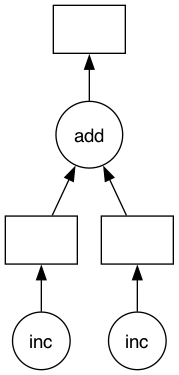

In [ ]:
import dask.delayed as delayed
from dask.diagnostics import ProgressBar

def inc(i):
    return i + 1

def add(x, y):
    return x + y

x = delayed(inc)(1)
y = delayed(inc)(2)
z = delayed(add)(x, y)

z.visualize()

### Visualizing More Complex DAGs with Loops and Collections

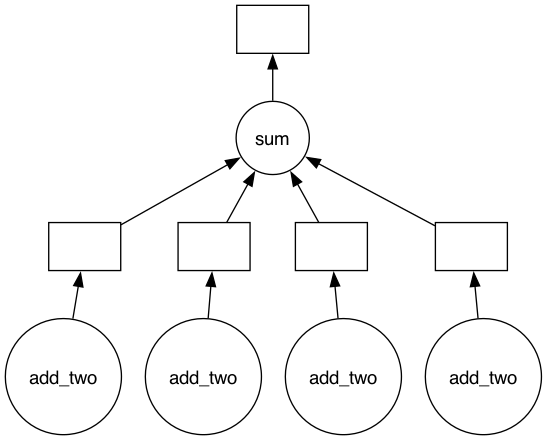

In [ ]:
# Listing 2.7
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
total = delayed(sum)(step1)
total.visualize()

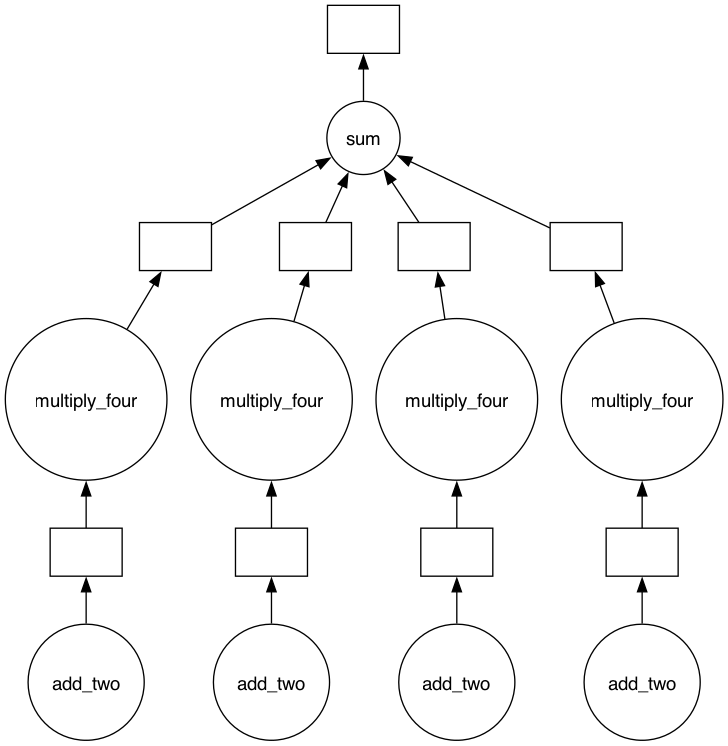

In [ ]:
def add_two(x):
    return x + 2

def sum_two_numbers(x,y):
    return x + y

def multiply_four(x):
    return x * 4

data = [1, 5, 8, 10]

step1 = [delayed(add_two)(i) for i in data]
step2 = [delayed(multiply_four)(j) for j in step1]
total = delayed(sum)(step2)
total.visualize()

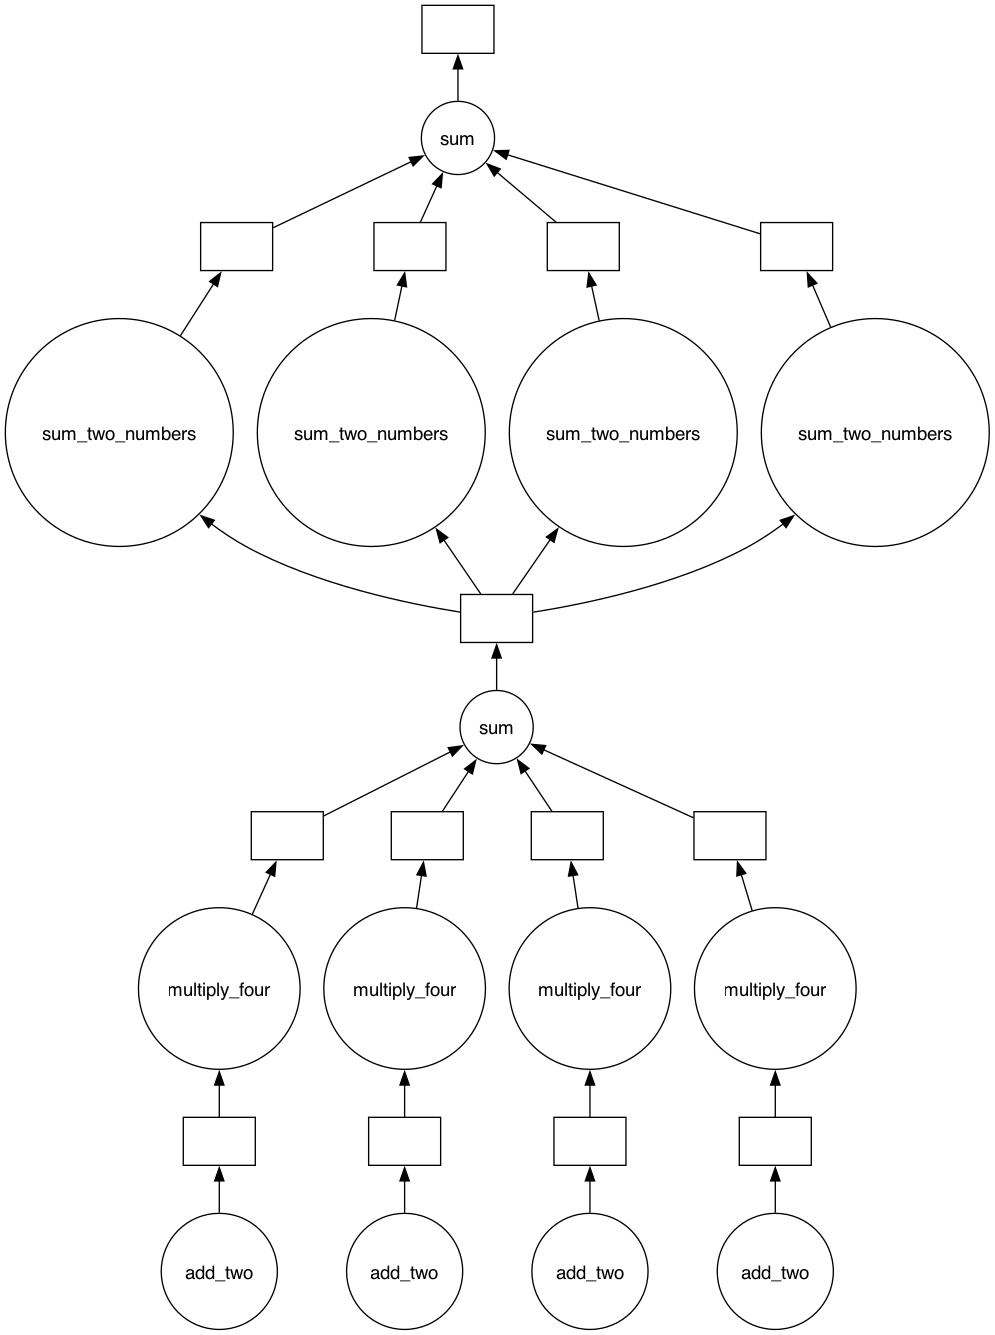

In [ ]:
data2 = [delayed(sum_two_numbers)(k, total) for k in data]
total2 = delayed(sum)(data2)
total2.visualize()

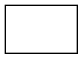

In [ ]:
total_persisted = total.persist()
total_persisted.visualize()

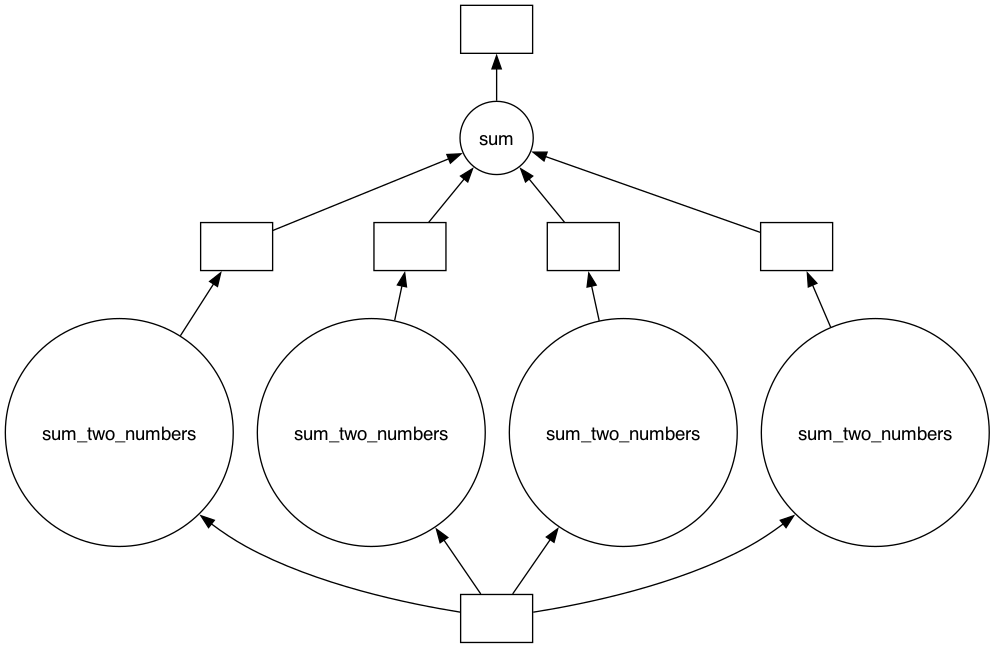

In [ ]:
data2 = [delayed(sum_two_numbers)(l, total_persisted) for l in data]
total2 = delayed(sum)(data2)
total2.visualize()

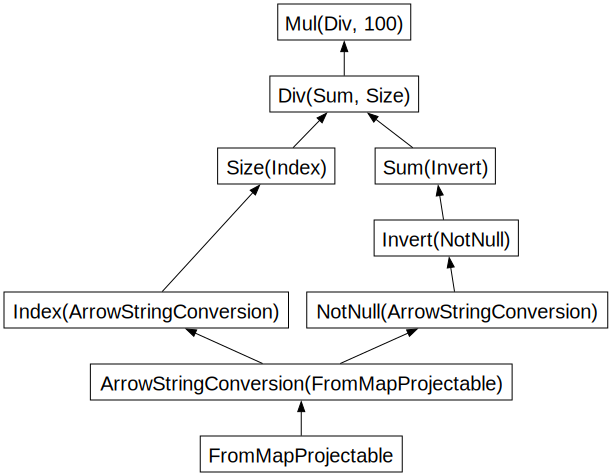

In [ ]:
missing_count.visualize()